In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/ventilator-pressure-prediction/sample_submission.csv
/kaggle/input/ventilator-pressure-prediction/train.csv
/kaggle/input/ventilator-pressure-prediction/test.csv


In [2]:
# Load CSV files
train_df = pd.read_csv('../input/ventilator-pressure-prediction/train.csv')
test_df = pd.read_csv('../input/ventilator-pressure-prediction/test.csv')
submission = pd.read_csv('../input/ventilator-pressure-prediction/sample_submission.csv')

In [3]:
# Shape of train and test dataset
print("Shape of training data : {}".format(train_df.shape))
print("Shape of test data : {}".format(test_df.shape))

Shape of training data : (6036000, 8)
Shape of test data : (4024000, 7)


In [4]:
def add_features(df):
    # Moving average
    df["u_in_ma_lag1"] = df.groupby(["breath_id"])["u_in"].shift(1).rolling(window=3).mean()
#     df["u_in_ma_lag2"] = df.groupby(["breath_id"])["u_in"].shift(2).rolling(window=3).mean()
#     df["u_in_ma_lag3"] = df.groupby(["breath_id"])["u_in"].shift(3).rolling(window=3).mean()
#     df["u_in_ma_lag4"] = df.groupby(["breath_id"])["u_in"].shift(4).rolling(window=3).mean()
#     df["u_in_ma_lag5"] = df.groupby(["breath_id"])["u_in"].shift(5).rolling(window=3).mean()
    df["u_in_ma_lag-1"] = df.groupby(["breath_id"])["u_in"].shift(-1).rolling(window=3).mean()
#     df["u_in_ma_lag-2"] = df.groupby(["breath_id"])["u_in"].shift(-2).rolling(window=3).mean()
#     df["u_in_ma_lag-3"] = df.groupby(["breath_id"])["u_in"].shift(-3).rolling(window=3).mean()
#     df["u_in_ma_lag-4"] = df.groupby(["breath_id"])["u_in"].shift(-4).rolling(window=3).mean()
#     df["u_in_ma_lag-5"] = df.groupby(["breath_id"])["u_in"].shift(-5).rolling(window=3).mean()
    
    
    # Lag feature
    df["u_in_lag1"] = df.groupby(["breath_id"])["u_in"].shift(1)
#     df["u_in_lag2"] = df.groupby(["breath_id"])["u_in"].shift(2)
#     df["u_in_lag3"] = df.groupby(["breath_id"])["u_in"].shift(3)
#     df["u_in_lag4"] = df.groupby(["breath_id"])["u_in"].shift(4)
#     df["u_in_lag5"] = df.groupby(["breath_id"])["u_in"].shift(5)
    df["u_in_lag-1"] = df.groupby(["breath_id"])["u_in"].shift(-1)
#     df["u_in_lag-2"] = df.groupby(["breath_id"])["u_in"].shift(-2)
#     df["u_in_lag-3"] = df.groupby(["breath_id"])["u_in"].shift(-3)
#     df["u_in_lag-4"] = df.groupby(["breath_id"])["u_in"].shift(-4)
#     df["u_in_lag-5"] = df.groupby(["breath_id"])["u_in"].shift(-5)
    
    # u_in mean and std, u_out mean and std
    df["u_in_mean"] = df.groupby(['breath_id'])['u_in'].transform('mean')
    df["u_in_std"] = df.groupby(['breath_id'])['u_in'].transform('std')
    df["u_out_mean"] = df.groupby(['breath_id'])['u_out'].transform('mean')
    df["u_out_std"] = df.groupby(['breath_id'])['u_out'].transform('std')
    
    return df.fillna(0)
    

In [5]:
train_df = add_features(train_df)
test_df = add_features(test_df)

In [6]:
train_df.head(5)

,id,breath_id,R,C,time_step,u_in,u_out,pressure,u_in_ma_lag1,u_in_ma_lag-1,u_in_lag1,u_in_lag-1,u_in_mean,u_in_std,u_out_mean,u_out_std
0,1,1,20,50,0.000000,0.083334,0,5.837492,0.000000,0.000000,0.000000,18.383041,10.146007,10.12367,0.625,0.487177
1,2,1,20,50,0.033652,18.383041,0,5.907794,0.000000,0.000000,0.083334,22.509278,10.146007,10.12367,0.625,0.487177
2,3,1,20,50,0.067514,22.509278,0,7.876254,0.000000,21.233714,18.383041,22.808822,10.146007,10.12367,0.625,0.487177
3,4,1,20,50,0.101542,22.808822,0,11.742872,13.658551,23.557983,22.509278,25.355850,10.146007,10.12367,0.625,0.487177
4,5,1,20,50,0.135756,25.355850,0,12.234987,21.233714,25.141513,22.808822,27.259866,10.146007,10.12367,0.625,0.487177


In [7]:
# plt.figure(figsize=(15, 15))
# train_df_corr = train_df.drop(["id", "breath_id", "R", "C", "time_step"], axis=1)
# train_corr = train_df_corr.corr()
# sns.heatmap(train_corr, vmax=1, vmin=-1, center=0, annot=True)

In [8]:
# LightGBM
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from statistics import mean

folds = 4   # Number of fold
kf = KFold(n_splits=folds)

# Set LGBM hyper parameters
lgbm_params = {
    "objective":"regression",
    "random_seed":1234
}

# Set explanatory variable and Objective variable
train_x = train_df.drop(["id", "breath_id", "pressure"], axis=1)
train_y = train_df["pressure"]

In [9]:
# Train model and predict
models = []
rmses = []
preds = np.zeros(len(train_x))

num_boost_round = 20000
early_stopping_rounds = 1000
verbose_eval = 100

for train_index, val_index in kf.split(train_x):
    x_train = train_x.iloc[train_index]
    x_valid = train_x.iloc[val_index]
    y_train = train_y.iloc[train_index]
    y_valid = train_y.iloc[val_index]
    
    lgb_train = lgb.Dataset(x_train, y_train)
    lgb_eval = lgb.Dataset(x_valid, y_valid, reference=lgb_train)
    
    model_lgb = lgb.train(lgbm_params,
                         lgb_train,
                         valid_sets=lgb_eval,
                         num_boost_round=num_boost_round,
                         early_stopping_rounds=early_stopping_rounds,
                         verbose_eval=verbose_eval)
    
    y_pred = model_lgb.predict(x_valid, num_iteration=model_lgb.best_iteration)
    tmp_rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    print(tmp_rmse)
    
    models.append(model_lgb)
    rmses.append(tmp_rmse)
    preds[val_index] = y_pred
    


[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.118680 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2066
[LightGBM] [Info] Number of data points in the train set: 4527000, number of used features: 13
[LightGBM] [Info] Start training from score 11.214635
Training until validation scores don't improve for 1000 rounds
[100]	valid_0's l2: 2.22484
[200]	valid_0's l2: 1.73647
[300]	valid_0's l2: 1.50696
[400]	valid_0's l2: 1.36289
[500]	valid_0's l2: 1.27985
[600]	valid_0's l2: 1.19526
[700]	valid_0's l2: 1.149
[800]	valid_0's l2: 1.1132
[900]	valid_0's l2: 1.08111
[1000]	valid_0's l2: 1.05242
[1100]	valid_0's l2: 1.02728
[1200]	valid_0's l2: 1.00599
[1300]	valid_0's l2: 0.985456
[1400]	valid_0's l2: 0.96201
[1500]	valid_0's l2: 0.9454
[1600]	valid_0's l2: 0.928722
[1700]	valid_0's l2: 0.915165
[1800]	valid_0's l2: 0.902561
[1900]	valid

In [10]:
# Calculate average of RMSE
mean(rmses)

0.7815342286601131

<AxesSubplot:>

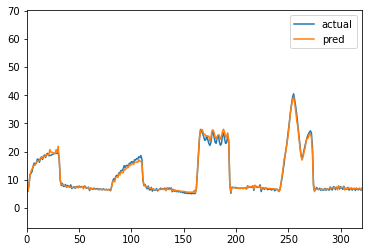

In [11]:
# Plot actual and pred
actual_pred_df = pd.DataFrame({
    "actual" : train_y,
    "pred" : preds
})

actual_pred_df.plot(xlim=[0,320])

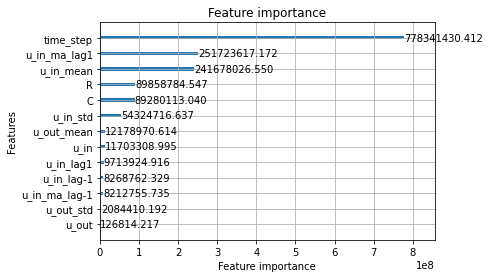

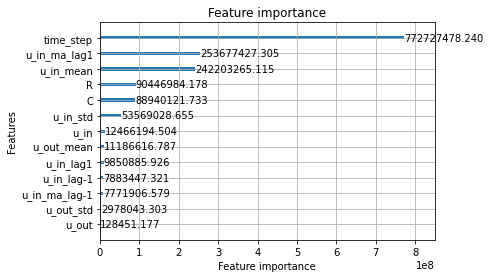

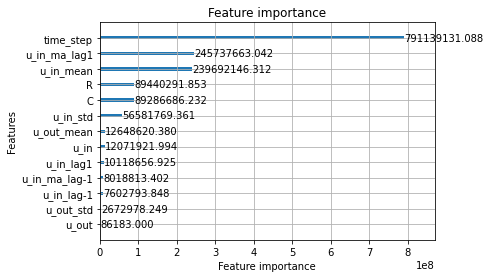

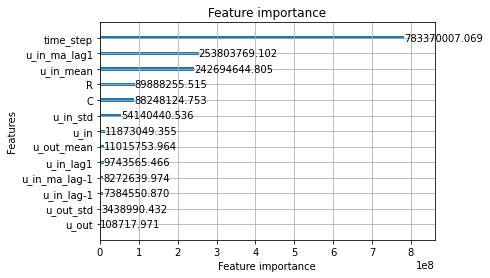

In [12]:
# Plot variables importance
for model in models:
    lgb.plot_importance(model, importance_type="gain")

In [13]:
# Create submit data
test_x = test_df.drop(["id", "breath_id"], axis=1)

submit_preds = []

for model in models:
    submit_pred = model.predict(test_x)
    submit_preds.append(submit_pred)

# Calculate mean
preds_array = np.array(submit_preds)
preds_mean = np.mean(preds_array, axis=0)

In [14]:
# Create submit file
submission["pressure"] = preds_mean
submission.to_csv("ventilator_submit01.csv", index=False)

### 